/tmp/ipykernel_2657/67011020.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


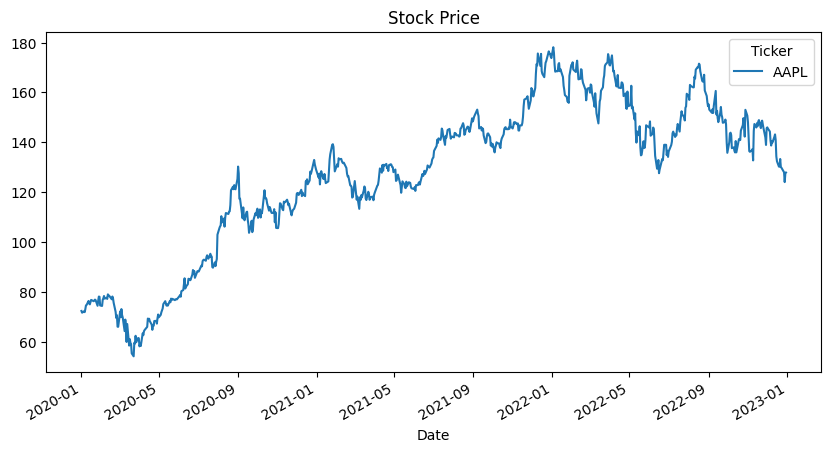

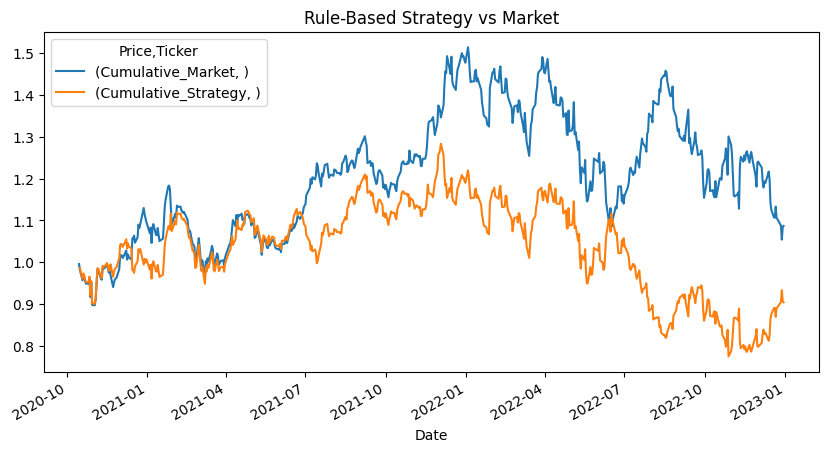


--- Rule-Based Strategy ---
Total Return: 0.90464379675006
Sharpe Ratio: 0.008817034875640069
Max Drawdown: -0.3956458649885539

--- ML Model ---
Train Accuracy: 1.0
Test Accuracy: 0.48214285714285715

Confusion Matrix:
[[36 27]
 [31 18]]


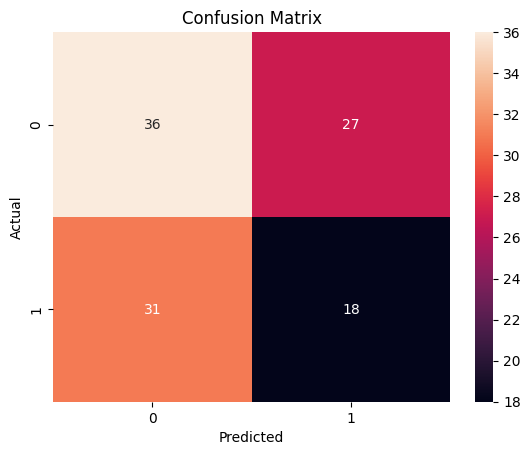


--- ML Strategy Performance ---
Strategy Return: 0.8895129352490129
Market Return: 0.8457802905972596
Sharpe Ratio: -0.5333251247204597
Max Drawdown: -0.3168666409511107


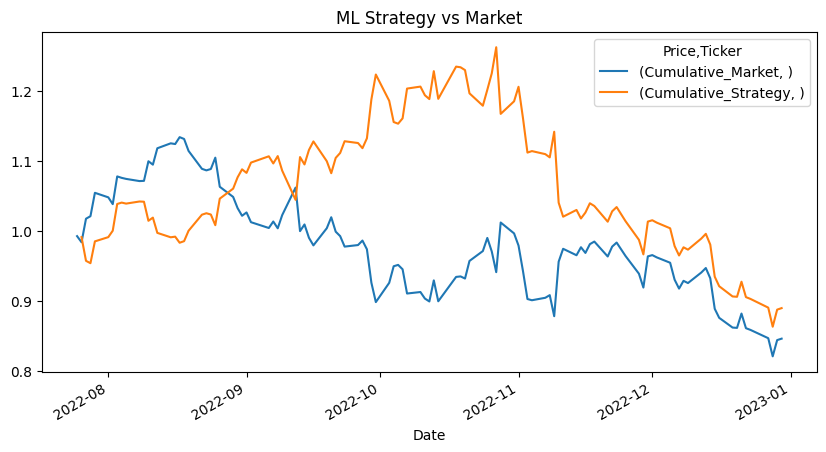

In [1]:
# =========================
# AI TRADING STRATEGY (FINAL PROFESSIONAL VERSION)
# =========================

# Install (only in Colab)
!pip install yfinance

# =========================
# IMPORTS
# =========================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# =========================
# STEP 1: LOAD DATA
# =========================

data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

# =========================
# STEP 2: BASIC VISUALIZATION
# =========================

data["Close"].plot(figsize=(10,5))
plt.title("Stock Price")
plt.show()

# =========================
# STEP 3: FEATURE ENGINEERING
# =========================

# Moving Averages
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

# Returns
data["Returns"] = data["Close"].pct_change()

# RSI
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
data["RSI"] = 100 - (100 / (1 + rs))

data = data.dropna()

# =========================
# STEP 4: RULE-BASED STRATEGY
# =========================

data["Signal"] = 0

# Buy
data.loc[(data["MA50"] > data["MA200"]) & (data["RSI"] < 70), "Signal"] = 1

# Sell
data.loc[(data["MA50"] < data["MA200"]) | (data["RSI"] > 70), "Signal"] = -1

# =========================
# STEP 5: BACKTEST RULE STRATEGY
# =========================

data["Strategy_Returns"] = data["Returns"] * data["Signal"].shift(1)

data["Cumulative_Market"] = (1 + data["Returns"]).cumprod()
data["Cumulative_Strategy"] = (1 + data["Strategy_Returns"]).cumprod()

data[["Cumulative_Market","Cumulative_Strategy"]].plot(figsize=(10,5))
plt.title("Rule-Based Strategy vs Market")
plt.show()

# =========================
# STEP 6: METRICS (RULE STRATEGY)
# =========================

print("\n--- Rule-Based Strategy ---")

print("Total Return:", data["Cumulative_Strategy"].iloc[-1])

sharpe = np.sqrt(252) * data["Strategy_Returns"].mean() / data["Strategy_Returns"].std()
print("Sharpe Ratio:", sharpe)

drawdown = data["Cumulative_Strategy"] / data["Cumulative_Strategy"].cummax() - 1
print("Max Drawdown:", drawdown.min())

# =========================
# STEP 7: ML STRATEGY
# =========================

# Target
data["Target"] = (data["Returns"].shift(-1) > 0).astype(int)
data = data.dropna()

features = ["MA50","MA200","RSI"]

X = data[features]
y = data["Target"]

# Time-based split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("\n--- ML Model ---")
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

# =========================
# CONFUSION MATRIX (IMPORTANT)
# =========================

cm = confusion_matrix(y_test, test_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualization
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# STEP 8: BACKTEST ML STRATEGY
# =========================

test_data = data.loc[X_test.index].copy()

test_data["Signal"] = test_pred
test_data["Signal"] = test_data["Signal"].replace(0, -1)

test_data["Strategy_Returns"] = test_data["Returns"] * test_data["Signal"].shift(1)

test_data["Cumulative_Market"] = (1 + test_data["Returns"]).cumprod()
test_data["Cumulative_Strategy"] = (1 + test_data["Strategy_Returns"]).cumprod()

# =========================
# STEP 9: ML METRICS
# =========================

print("\n--- ML Strategy Performance ---")

total_return = test_data["Cumulative_Strategy"].iloc[-1]
market_return = test_data["Cumulative_Market"].iloc[-1]

sharpe = np.sqrt(252) * test_data["Strategy_Returns"].mean() / test_data["Strategy_Returns"].std()

drawdown = test_data["Cumulative_Strategy"] / test_data["Cumulative_Strategy"].cummax() - 1
max_drawdown = drawdown.min()

print("Strategy Return:", total_return)
print("Market Return:", market_return)
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_drawdown)

# =========================
# STEP 10: FINAL PLOT
# =========================

test_data[["Cumulative_Market","Cumulative_Strategy"]].plot(figsize=(10,5))
plt.title("ML Strategy vs Market")

plt.savefig("performance.png")

plt.show()